In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [4]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('exoplanet_data.csv')

data['radius'] = data['pl_rade']
data['mass'] = data['pl_bmasse']
data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)
data = data.drop_duplicates('radius')
data = data.reset_index(drop = True)
data

,radius,mass
0,0.320000,10.00000
1,0.470000,4.30000
2,0.500000,0.10000
3,0.510000,99.20000
4,0.540000,4.00000
...,...,...
1136,23.538859,375.03752
1137,24.660000,5403.00000
1138,30.264300,3496.13000
1139,33.600000,6356.00000


In [5]:
x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)

x, y

(0      -0.494850
 1      -0.327902
 2      -0.301030
 3      -0.292430
 4      -0.267606
           ...   
 1136    1.371785
 1137    1.391993
 1138    1.480931
 1139    1.526339
 1140    1.888416
 Name: radius, Length: 1141, dtype: float64,
 0       1.000000
 1       0.633468
 2      -1.000000
 3       1.996512
 4       0.602060
           ...   
 1136    2.574075
 1137    3.732635
 1138    3.543588
 1139    3.803184
 1140    3.431612
 Name: mass, Length: 1141, dtype: float64)

In [6]:
import dill
import matplotlib.pyplot as plot
import numpy

with open('radius_mass_spline.pkl', 'rb') as file:
    spline = dill.load(file)

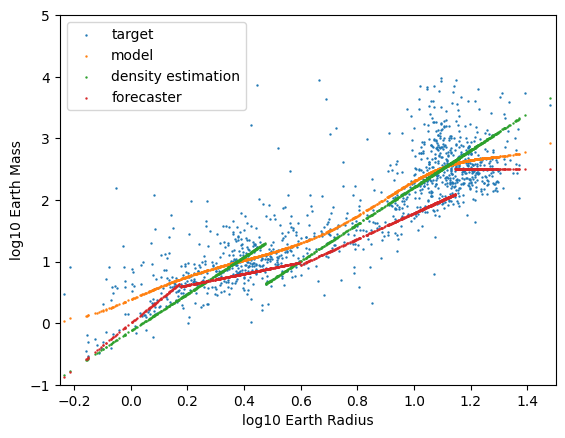

In [16]:
m = spline(x) # model
_x = numpy.power(10, x)

m2 = x.copy()
m2[_x < 3] = numpy.log10(((5 / 5.51) * _x) ** 3) # earth density estimation
m2[_x >= 3] = numpy.log10(((3 / 5.51) * _x) ** 3) # jupiter density estimation

m3 = x.copy()
m3[_x < 1.5] = _x[_x < 1.5] ** 3.7
m3[(_x >= 1.5) & (_x < 4.0)] = 2.69 * _x[(_x >= 1.5) & (_x < 4.0)] ** 0.93
m3[(_x >= 4.0) & (_x < 14.0)] = 0.486 * _x[(_x >= 4.0) & (_x < 14.0)] ** 2.1
m3[_x >= 14.0] = 318.0
m3 = numpy.log10(m3) # simplified chen and kipping

plot.scatter(x, y, s = 0.5)
plot.scatter(x, m, s = 0.5)
plot.scatter(x, m2, s = 0.5)
plot.scatter(x, m3, s = 0.5)

plot.legend(['target', 'model', 'density estimation', 'forecaster'])
plot.xlabel('log10 Earth Radius')
plot.ylabel('log10 Earth Mass')
plot.xlim(-0.25, 1.5)
plot.ylim(-1, 5)
plot.show()

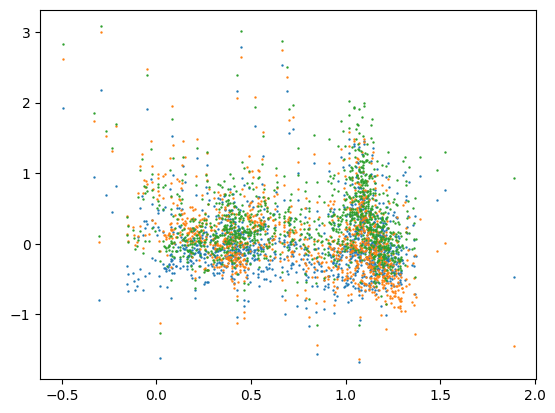

In [17]:
r = y - m
r2 = y - m2
r3 = y - m3
plot.scatter(x, r, s = 0.5)
plot.scatter(x, r2, s = 0.5)
plot.scatter(x, r3, s = 0.5)
plot.show()

In [18]:
print(numpy.mean(numpy.abs(r)))
print(numpy.mean(numpy.abs(r2)))
print(numpy.mean(numpy.abs(r3)))

0.34215071016923154
0.38726831946940626
0.42367585748778847
